## Lab 11: Procesamiento de Datos para Machine Learning
*Objetivo:* Aplicar las principales técnicas de preprocesamiento de datos para preparar un DataSet antes de entrenar un modelo de ML.

*Problema:* Se desea contruir un modelo capaz de predecir si un pasajero sobrevivio o no al hundimiento del Titanic.

In [3]:
#Importamos Librerias
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
import kagglehub

In [5]:
path = kagglehub.dataset_download("yasserh/titanic-dataset")

In [6]:
print("Ruta del dataset:", path)

Ruta del dataset: C:\Users\Ale\.cache\kagglehub\datasets\yasserh\titanic-dataset\versions\1


In [7]:
dfTitanic = pd.read_csv(path + "/Titanic-Dataset.csv")

In [8]:
dfTitanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [9]:
dfTitanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Parte 1. Comprension del problema
Determinar si sobreviven al hundimiento del titanic, con base en la informacion obtenida.

Survived
0- No sobrevivio
1- Sobrevivio

In [10]:
dfTitanic["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

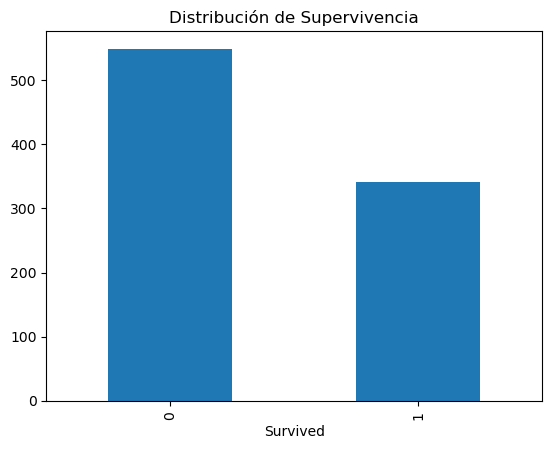

In [11]:
#Graficamos 
dfTitanic["Survived"].value_counts().plot(
    kind="bar"
)
plt.title("Distribución de Supervivencia")
plt.show()

## Parte 2. Hipótesis Inicial

In [12]:
#Hipotesis inicial
dfTitanic.groupby(
    "Sex"
) ["Survived"].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [13]:
dfTitanic.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [14]:
dfTitanic.groupby(
    "Pclass"
)["Survived"].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

In [15]:
dfTitanic.groupby(
    "Fare"
)["Survived"].mean()

Fare
0.0000      0.066667
4.0125      0.000000
5.0000      0.000000
6.2375      0.000000
6.4375      0.000000
              ...   
227.5250    0.750000
247.5208    0.500000
262.3750    1.000000
263.0000    0.500000
512.3292    1.000000
Name: Survived, Length: 248, dtype: float64

## Parte 3. Correlación e Hipótesis

Creamos una matriz de correlacion para identificar la relacion lineal entre las variables. No identifica la importancia de variables en el modelo.

In [16]:
variables_numericas = [
    "Survived",
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare"
]

In [17]:
corr = dfTitanic[variables_numericas].corr()

In [18]:
corr

,Survived,Pclass,Age,SibSp,Parch,Fare
Survived,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


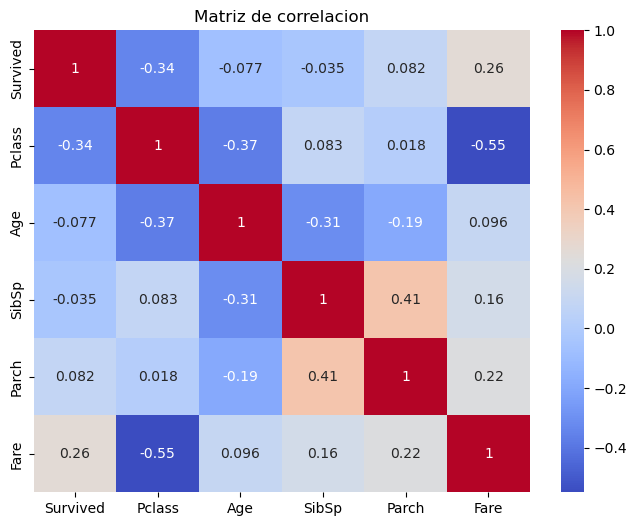

In [19]:
plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)
plt.title("Matriz de correlacion")
plt.show()

# Parte 4. Seleccion de variables Predictoras y Variable objetivo

X- Variables que utilizara el modelo

Y- Variables que queremos predecir

In [20]:
columnas = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked"
]

In [21]:
# Definimos x y
X = dfTitanic[columnas]
y = dfTitanic["Survived"]

In [22]:
print(X.columns.tolist())

['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']


In [23]:
print(y.name)

Survived


## Parte 5.Tratamiento de valores
Para simplificar el proceso, realizaremos la imputacion de los datos antes de la separacion TRAIN/TEST

In [24]:
#Revisamos las variables predictoras
X.isnull().sum()

Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64

In [25]:
X["Age"] = X["Age"].fillna(
    X["Age"].median()
)

C:\Users\Ale\AppData\Local\Temp\ipykernel_10972\2953535474.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["Age"] = X["Age"].fillna(


In [26]:
X["Embarked"] = X["Embarked"].fillna(
    X["Embarked"].mode()[0]
)

C:\Users\Ale\AppData\Local\Temp\ipykernel_10972\3303780736.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["Embarked"] = X["Embarked"].fillna(


In [27]:
X.isnull().sum()

Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

In [28]:
X.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,22.0,1,0,7.2500,S
1,1,female,38.0,1,0,71.2833,C
2,3,female,26.0,0,0,7.9250,S
3,1,female,35.0,1,0,53.1000,S
4,3,male,35.0,0,0,8.0500,S


## Parte 6. Escalado de los datos
Los algoritmos no entienden texto. Se deben convertir las variables categoricas en variables numericas.

In [29]:
X = pd.get_dummies(
    X,
    columns =["Sex","Embarked"],
    drop_first= True
)

In [30]:
X.head()

,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,3,22.0,1,0,7.2500,True,False,True
1,1,38.0,1,0,71.2833,False,False,False
2,3,26.0,0,0,7.9250,False,False,True
3,1,35.0,1,0,53.1000,False,False,True
4,3,35.0,0,0,8.0500,True,False,True


## Parte 7. Particionamos los datos
No debemos entrenar y evaluar utilizando los mismos datos.

La recomendacion es:

Entrenamiento 80% 

Pruebas 20%

In [31]:
X_train,X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.20,
    random_state= 42
)

In [32]:
print("Entrenamiento:", X_train.shape)

Entrenamiento: (712, 8)


In [33]:
print("Prueba:", y_test.shape)

Prueba: (179,)


In [34]:
variables_numericas

['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

## Parte 8. Escalado de las variables

Las variables numericas tienen valores distintos. El escalado evita que una variable domine mas que otra.

In [35]:
columnas_numericas = [
    "Age",
    "Fare",
    "SibSp",
    "Parch"
]

In [36]:
X_train[columnas_numericas].describe()

,Age,Fare,SibSp,Parch
count,712.000000,712.000000,712.000000,712.000000
mean,29.204129,32.586276,0.553371,0.379213
std,13.007971,51.969529,1.176404,0.791669
min,0.420000,0.000000,0.000000,0.000000
25%,22.000000,7.925000,0.000000,0.000000
50%,28.000000,14.454200,0.000000,0.000000
75%,35.000000,30.500000,1.000000,0.000000
max,80.000000,512.329200,8.000000,6.000000


In [37]:
scaler = StandardScaler()
X_train[columnas_numericas] = scaler.fit_transform(
    X_train[columnas_numericas]
)
X_test[columnas_numericas] = scaler.transform(
    X_test[columnas_numericas]
)

In [38]:
X_train[columnas_numericas].describe()

,Age,Fare,SibSp,Parch
count,7.120000e+02,7.120000e+02,7.120000e+02,7.120000e+02
mean,1.746418e-17,5.363999e-17,1.746418e-17,2.245395e-17
std,1.000703e+00,1.000703e+00,1.000703e+00,1.000703e+00
min,-2.214363e+00,-6.274674e-01,-4.707224e-01,-4.793416e-01
25%,-5.542135e-01,-4.748670e-01,-4.707224e-01,-4.793416e-01
50%,-9.263364e-02,-3.491435e-01,-4.707224e-01,-4.793416e-01
75%,4.458762e-01,-4.017244e-02,3.799232e-01,-4.793416e-01
max,3.907725e+00,9.237724e+00,6.334442e+00,7.104908e+00


## Parte 9. Entrenamineto de los datos
Usaremos un arbol de decision para clasificar registros

In [39]:
modelo = DecisionTreeClassifier (
    max_depth = 4,
    random_state= 42,
)

In [40]:
modelo.fit(
    X_train,
    y_train
)

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


## Parte 10. Evaluamos el modelo
Realizamos predicciones para evaluar el modelo

In [41]:
predicciones = modelo.predict(
    X_test
)

In [42]:
pd.DataFrame({
    "Real": y_test,
    "Prediccion": predicciones
}).head(30)

,Real,Prediccion
709,1,0
439,0,0
840,0,0
720,1,1
39,1,1
290,1,1
300,1,1
333,0,0
208,1,1
136,1,1


## Parte 11. Evaluacion del modelo
El accuracy determina el porcentaje de predicciones correctas realizadas por el modelo.

In [43]:
accuracy = accuracy_score(
    y_test,
    predicciones
)

In [44]:
print (f"Accuracy: {accuracy: .4f}")

Accuracy:  0.7989


|Accurracy| Interpretacion|
|---------|---------------|
| 50% | Adivina |
| 60-70% | Aceptable / Basico |
| 70-80% | Bueno |
| 80-90% | Muy bueno |
| >90% | Excelente (posible sobreajuste) |

## Parte 12. Importancia de las variables
Analizar las variables mas relevantes para el algoritmo, al realizar las predicciones.

In [45]:
importancias = pd.DataFrame({
    "Variable" : X_train.columns,
    "Importancia" : modelo.feature_importances_ #Que variable es importante para el modelo
})

In [46]:
importancias.sort_values(
    by="Importancia",
    ascending=False
)

,Variable,Importancia
5,Sex_male,0.579608
0,Pclass,0.200498
4,Fare,0.081064
1,Age,0.078872
2,SibSp,0.046059
7,Embarked_S,0.013900
3,Parch,0.000000
6,Embarked_Q,0.000000
